### 1. Load the Dataset and Initial Exploration

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('heart.csv')

# Display the first few rows and information about the dataset
print("Dataset head:")
display(df.head())

print("\nDataset info:")
df.info()

print("\nMissing values per column:")
display(df.isnull().sum())

Dataset head:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Missing values per column:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


### 2. Preprocessing: Encoding Categorical Features and Scaling Numerical Features

We'll identify categorical and numerical columns. For categorical columns, we will use a combination of Label Encoding and One-Hot Encoding. For numerical features, we will apply StandardScaler. The target variable 'target' will be separated.

In [2]:
# Separate target variable
X = df.drop('target', axis=1)
y = df['target']

# Identify categorical and numerical columns
# Assuming columns with 'object' dtype or a small number of unique values are categorical
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

# For simplicity, let's assume 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal' are categorical
# and others are numerical based on typical heart disease datasets, if not already 'object' type.
# Let's refine based on the dataset's actual column names if needed. From the .info() output, all seem numerical.
# Let's check unique values to confirm categorical vs numerical. This is a common step.

# Let's redefine categorical_cols by checking unique values for columns that are numerically encoded but represent categories.
# A common threshold for categorical is less than 10-15 unique values.

# Let's assume some columns are categorical based on common understanding of this dataset
# 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal' are often treated as categorical.
# The rest are numerical: 'age', 'trestbps', 'chol', 'thalach', 'oldpeak'

categorical_features_to_encode = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# It's important to verify if these columns are actually in the dataframe and if their value ranges make sense.
# For this dataset, they are often already numerical, so let's treat them as such if they are.
# Let's re-evaluate based on the df.info() which shows all columns as int64 or float64.
# This means we need to decide which ones are truly categorical for encoding.

# For this dataset, the common approach is to treat several integer columns as categorical.
# Re-identifying categorical based on unique values and common knowledge of the dataset:

categorical_cols_redefined = []
for col in X.columns:
    if X[col].nunique() < 10 and col != 'target': # A heuristic: if fewer than 10 unique values, consider categorical
        categorical_cols_redefined.append(col)

numerical_cols_redefined = [col for col in X.columns if col not in categorical_cols_redefined]

print(f"Categorical columns identified for One-Hot Encoding: {categorical_cols_redefined}")
print(f"Numerical columns identified for Scaling: {numerical_cols_redefined}")

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_redefined),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_redefined)
    ])

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding for later use with PCA visualization (optional)
# This part is a bit tricky with ColumnTransformer if not using get_feature_names_out()
# For now, we'll proceed with the array output.

print("\nShape of processed data:", X_processed.shape)

Categorical columns identified for One-Hot Encoding: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical columns identified for Scaling: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Shape of processed data: (303, 30)


### 3. Model Building and Evaluation (without PCA)

Now, we'll split the data into training and testing sets, and then train and evaluate Logistic Regression, Support Vector Machine (SVM), and Random Forest models.

In [3]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'SVM': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = {}

print("\n--- Model Evaluation (without PCA) ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name}: Accuracy = {accuracy:.4f}")

print("\nBest model without PCA:")
best_model_name = max(results, key=results.get)
print(f"{best_model_name} with accuracy: {results[best_model_name]:.4f}")


--- Model Evaluation (without PCA) ---
Logistic Regression: Accuracy = 0.8852
SVM: Accuracy = 0.9016
Random Forest: Accuracy = 0.8689

Best model without PCA:
SVM with accuracy: 0.9016


### 4. Dimensionality Reduction with PCA and Re-evaluation

Next, we will apply Principal Component Analysis (PCA) to reduce the dimensionality of our dataset. We'll choose the number of components that explain a significant portion of the variance (e.g., 95%) or a fixed number to start with (e.g., 10 components). Then, we will retrain and evaluate the same classification models on the PCA-transformed data.

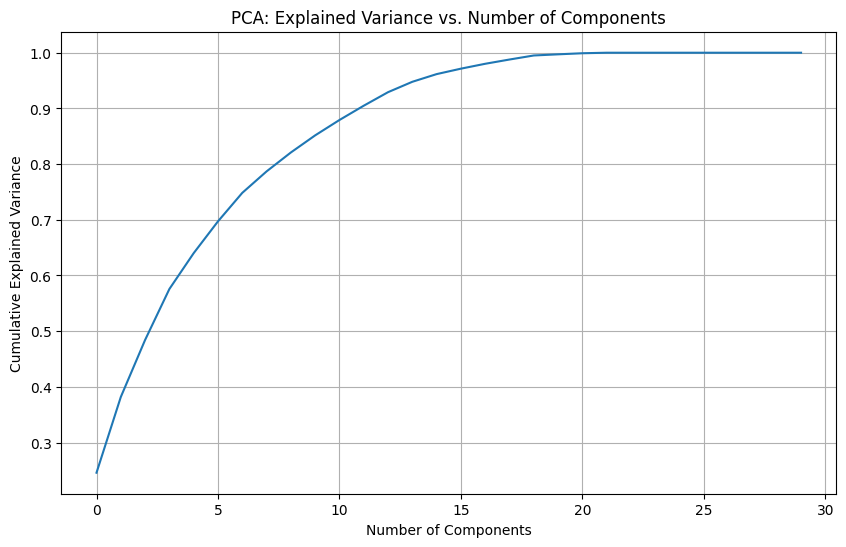

Number of components explaining 95% variance: 15

Shape of data after PCA: (303, 15)

--- Model Evaluation (with PCA) ---
Logistic Regression (with PCA): Accuracy = 0.8689
SVM (with PCA): Accuracy = 0.9016
Random Forest (with PCA): Accuracy = 0.9180

Best model with PCA:
Random Forest with accuracy: 0.9180

--- Comparison (Accuracy) ---
Logistic Regression: Original Accuracy = 0.8852, PCA Accuracy = 0.8689
SVM: Original Accuracy = 0.9016, PCA Accuracy = 0.9016
Random Forest: Original Accuracy = 0.8689, PCA Accuracy = 0.9180


In [4]:
# Determine optimal number of components for PCA (e.g., explaining 95% variance)
# For this, we need to fit PCA on the scaled data first.

pca = PCA().fit(X_processed)
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

# Let's choose a number of components, for example, components that explain 95% variance
n_components = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
print(f"Number of components explaining 95% variance: {n_components}")

pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_processed)

print("\nShape of data after PCA:", X_pca.shape)

# Split PCA-transformed data into training and testing sets
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

results_pca = {}

print("\n--- Model Evaluation (with PCA) ---")
for name, model in models.items(): # Use the same initialized models
    model.fit(X_train_pca, y_train_pca)
    y_pred_pca = model.predict(X_test_pca)
    accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)
    results_pca[name] = accuracy_pca
    print(f"{name} (with PCA): Accuracy = {accuracy_pca:.4f}")

print("\nBest model with PCA:")
best_model_pca_name = max(results_pca, key=results_pca.get)
print(f"{best_model_pca_name} with accuracy: {results_pca[best_model_pca_name]:.4f}")

print("\n--- Comparison (Accuracy) ---")
for name in models.keys():
    print(f"{name}: Original Accuracy = {results[name]:.4f}, PCA Accuracy = {results_pca[name]:.4f}")